# Student Performance Analysis: Factors Affecting Academic Performance 

Analyze student academic performance and identify how study hours, attendance, previous scores, gender, and other factors are associated with final academic performance.

## Import all Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1 — Load the dataset 

In [2]:
df = pd.read_csv('Student_Performance_Dataset.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


In [4]:
df.shape

(5000, 16)

In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 5000
Number of Columns: 16


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   str    
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   str    
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   str    
 7   Internet_Access             5000 non-null   str    
 8   Extracurricular_Activities  5000 non-null   str    
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 non-null   

In [7]:
df.describe()

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


## Step 2 — Clean the data 

In [8]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Class                         0
Study_Hours_Per_Day           0
Attendance_Percentage         0
Parental_Education            0
Internet_Access               0
Extracurricular_Activities    0
Math_Score                    0
Science_Score                 0
English_Score                 0
Previous_Year_Score           0
Final_Percentage              0
Performance_Level             0
Pass_Fail                     0
dtype: int64

The dataset contained no missing values, so no imputation is required.

In [9]:
df.duplicated().sum()

np.int64(0)

No duplicate records found

In [10]:
df.dtypes

Student_ID                        str
Age                             int64
Gender                            str
Class                           int64
Study_Hours_Per_Day           float64
Attendance_Percentage           int64
Parental_Education                str
Internet_Access                   str
Extracurricular_Activities        str
Math_Score                      int64
Science_Score                   int64
English_Score                   int64
Previous_Year_Score             int64
Final_Percentage              float64
Performance_Level                 str
Pass_Fail                         str
dtype: object

### Check Unique Values

In [11]:
print("Gender:")
print(df["Gender"].unique())

print("\nParental Education:")
print(df["Parental_Education"].unique())

print("\nInternet Access:")
print(df["Internet_Access"].unique())

print("\nExtracurricular Activities:")
print(df["Extracurricular_Activities"].unique())

print("\nPerformance Level:")
print(df["Performance_Level"].unique())

print("\nPass/Fail:")
print(df["Pass_Fail"].unique())

Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Parental Education:
<StringArray>
['Postgraduate', 'Graduate', 'High School']
Length: 3, dtype: str

Internet Access:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Extracurricular Activities:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Performance Level:
<StringArray>
['Average', 'Good', 'Poor', 'Excellent']
Length: 4, dtype: str

Pass/Fail:
<StringArray>
['Pass', 'Fail']
Length: 2, dtype: str


# Step 3 — Data Validation #

1. Calulate Avarage Marks of all subjects

In [12]:
df['Final_Score'] = df[['Math_Score','Science_Score','English_Score']].mean(axis=1).round(2)
df['Final_Score']

0       50.33
1       53.00
2       71.67
3       64.33
4       41.00
        ...  
4995    64.67
4996    48.67
4997    72.67
4998    57.33
4999    69.67
Name: Final_Score, Length: 5000, dtype: float64

Subject Wise Average Score

In [13]:
print("Average Math Score:", df['Math_Score'].mean())
print("Average Science Score:", df['Science_Score'].mean())
print("Average English Score:", df['English_Score'].mean())
print("Average Final Score:", df['Final_Score'].mean())

Average Math Score: 67.7548
Average Science Score: 66.8954
Average English Score: 67.7828
Average Final Score: 67.47765600000001


2. Highest and Lowest Marks in each subject

In [14]:
print("Maths_Highest_Marks - ", df['Math_Score'].max())
print("Science_Highest_Marks - ", df['Science_Score'].max())
print("English_Highest_Marks - ", df['English_Score'].max())

print("Maths_Lowest_Marks - ", df['Math_Score'].min())
print("Science_Lowest_Marks - ", df['Science_Score'].min())
print("English_Lowest_Marks - ", df['English_Score'].min())


Maths_Highest_Marks -  100
Science_Highest_Marks -  100
English_Highest_Marks -  100
Maths_Lowest_Marks -  35
Science_Lowest_Marks -  35
English_Lowest_Marks -  35


3. Avarage Attendence Percentage

In [15]:
print("Average Attendance:", round(df['Attendance_Percentage'].mean(), 2))

Average Attendance: 74.92


4. Total Students

In [16]:
print("Total number of students: ", df['Student_ID'].nunique())

Total number of students:  5000


5. Pass/Fail Count

In [17]:
df['Pass_Fail'].value_counts()

Pass_Fail
Pass    4735
Fail     265
Name: count, dtype: int64

6. Subject Wise Performance

In [18]:
df['Performance_Level'].value_counts()

Performance_Level
Good         2191
Average      1951
Excellent     593
Poor          265
Name: count, dtype: int64

In [19]:
df[['Math_Score', 'Science_Score', 'English_Score','Final_Percentage']].agg(['max','min','mean','count'])

,Math_Score,Science_Score,English_Score,Final_Percentage
max,100.0000,100.0000,100.0000,98.330000
min,35.0000,35.0000,35.0000,36.330000
mean,67.7548,66.8954,67.7828,67.477656
count,5000.0000,5000.0000,5000.0000,5000.000000


7. Gender Wise Performance

In [20]:
df.groupby('Gender')[['Math_Score', 'Science_Score', 'English_Score','Final_Percentage']].agg(['mean','min','max'])

Math_Score          Science_Score          English_Score           \
             mean min  max          mean min  max          mean min  max   
Gender                                                                     
Female  67.784567  35  100     66.910693  35  100     67.564434  35  100   
Male    67.723743  35  100     66.879444  35  100     68.010625  35  100   

       Final_Percentage                
                   mean    min    max  
Gender                                 
Female        67.419890  37.67  97.67  
Male          67.537924  36.33  98.33

In [21]:
pd.crosstab(df['Performance_Level'],df['Gender'])

Gender,Female,Male
Performance_Level,,
Average,1015,936
Excellent,299,294
Good,1105,1086
Poor,134,131


8. Study Hours Performance

In [22]:
print("Maximum Study Hours: ", df['Study_Hours_Per_Day'].max())
print("Minimum Study Hours: ", df['Study_Hours_Per_Day'].min())

Maximum Study Hours:  6.0
Minimum Study Hours:  0.5


In [23]:
study_performance = df.groupby('Study_Hours_Per_Day')['Final_Percentage'].mean().reset_index()

In [24]:
study_performance

,Study_Hours_Per_Day,Final_Percentage
0,0.5,67.719200
1,0.6,67.902697
2,0.7,69.656406
3,0.8,66.875814
4,0.9,66.231412
5,1.0,68.883012
6,1.1,67.959333
7,1.2,67.944167
8,1.3,68.690412
9,1.4,65.843542


In [25]:
print("Best Study Hour Group:", study_performance.idxmax())
print("Best Study Hour Group:", study_performance.max())

Best Study Hour Group: Study_Hours_Per_Day    55
Final_Percentage       31
dtype: int64
Best Study Hour Group: Study_Hours_Per_Day     6.000000
Final_Percentage       70.203093
dtype: float64


In [26]:
df.groupby('Study_Hours_Per_Day')[
    ['Math_Score', 'Science_Score', 'English_Score', 'Final_Percentage']
].mean()

,Math_Score,Science_Score,English_Score,Final_Percentage
Study_Hours_Per_Day,,,,
0.5,67.520000,68.300000,67.340000,67.719200
0.6,67.853933,69.820225,66.033708,67.902697
0.7,69.359375,70.625000,68.984375,69.656406
0.8,65.104651,67.860465,67.662791,66.875814
0.9,64.729412,67.435294,66.529412,66.231412
1.0,70.939759,67.506024,68.204819,68.883012
1.1,68.811111,71.377778,63.688889,67.959333
1.2,65.583333,69.904762,68.345238,67.944167
1.3,68.237113,67.721649,70.113402,68.690412


### Study Hours Group Analysis

In [27]:
df["Study_Hours_Group"] = pd.cut(
    df["Study_Hours_Per_Day"],
    bins=[0, 2, 4, 6, 8, np.inf],
    labels=[
        "0-2 Hours",
        "2-4 Hours",
        "4-6 Hours",
        "6-8 Hours",
        "8+ Hours"
    ]
)

In [28]:
study_group_analysis = df.groupby("Study_Hours_Group",observed=True)["Final_Percentage"].mean()
print(study_group_analysis)

Study_Hours_Group
0-2 Hours    67.683340
2-4 Hours    67.605471
4-6 Hours    67.191631
Name: Final_Percentage, dtype: float64


### Attendence Group Analysis 

In [29]:
df["Attendance_Group"] = pd.cut(
    df["Attendance_Percentage"],
    bins=[0, 60, 75, 90, 100],
    labels=[
        "Below 60%",
        "60-75%",
        "75-90%",
        "90-100%"
    ]
)

In [30]:
Attendance_Group_Analysis = df.groupby("Attendance_Group",observed = True)["Final_Percentage"].mean()
Attendance_Group_Analysis

Attendance_Group
Below 60%    67.475314
60-75%       67.383114
75-90%       67.717117
90-100%      67.264714
Name: Final_Percentage, dtype: float64

# Step 4 - Basic KPI Analysis

In [31]:
print("Total Students:", len(df))

print("Average Final Percentage:",
      round(df["Final_Percentage"].mean(), 2))

print("Average Attendance:",
      round(df["Attendance_Percentage"].mean(), 2))

print("Average Study Hours:",
      round(df["Study_Hours_Per_Day"].mean(), 2))

print("Average Math Score:",
      round(df["Math_Score"].mean(), 2))

print("Average Science Score:",
      round(df["Science_Score"].mean(), 2))

print("Average English Score:",
      round(df["English_Score"].mean(), 2))

Total Students: 5000
Average Final Percentage: 67.48
Average Attendance: 74.92
Average Study Hours: 3.29
Average Math Score: 67.75
Average Science Score: 66.9
Average English Score: 67.78


# Step 5 - Visualization

1. Study Hours Per Day vs Final Percentage

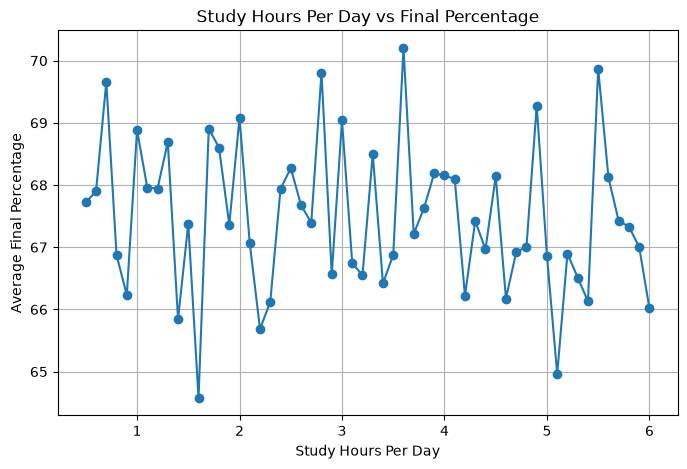

In [32]:
study_performance = df.groupby('Study_Hours_Per_Day')['Final_Percentage'].mean()

plt.figure(figsize=(8,5))
plt.plot(study_performance.index, study_performance.values, marker='o')
plt.title('Study Hours Per Day vs Final Percentage')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Average Final Percentage')
plt.grid(True)
plt.show()

2. Subject Wise Average Score

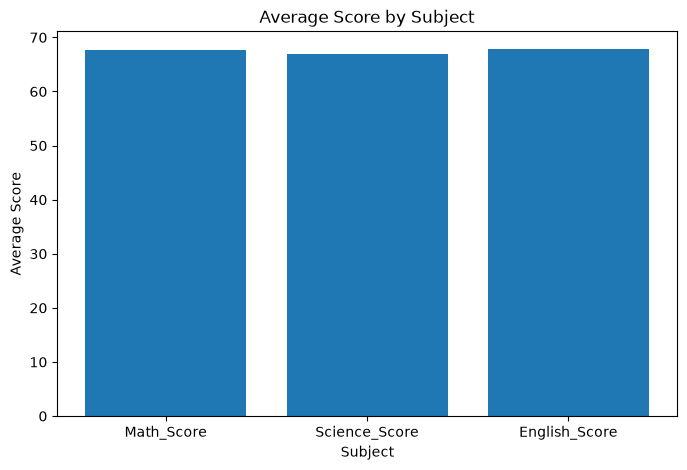

In [33]:
subject_avg = df[['Math_Score', 'Science_Score', 'English_Score']].mean()

plt.figure(figsize=(8,5))
plt.bar(subject_avg.index, subject_avg.values)
plt.title('Average Score by Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.show()

3. Attendance Percentage vs Final Percentage

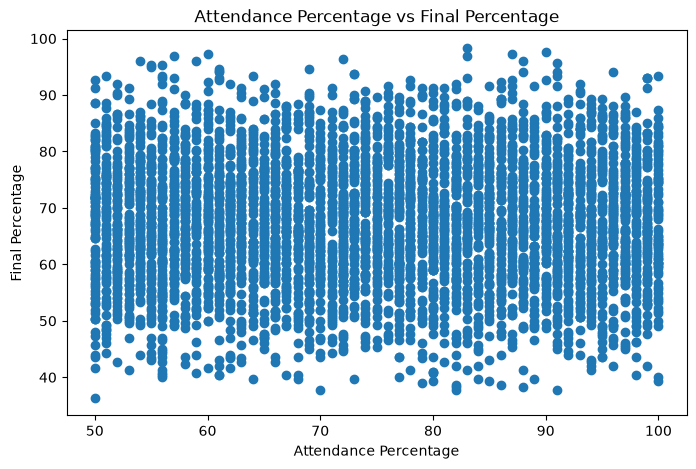

In [34]:
plt.figure(figsize = (8,5))
plt.scatter(df['Attendance_Percentage'], df['Final_Percentage'])
plt.title("Attendance Percentage vs Final Percentage")
plt.xlabel('Attendance Percentage')
plt.ylabel('Final Percentage')
plt.show()

4. Performance Distribution

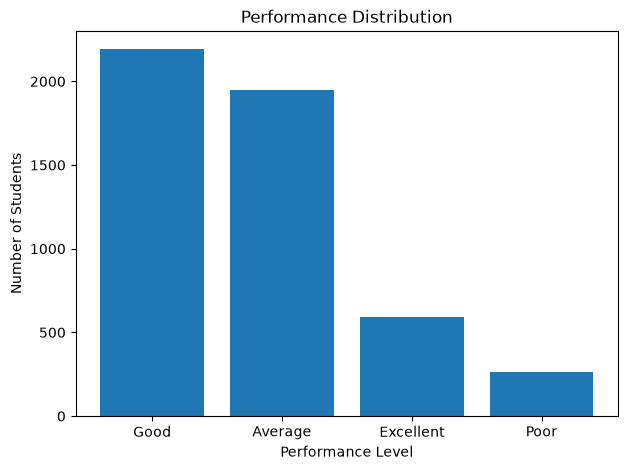

In [35]:
performance_count = df['Performance_Level'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(performance_count.index, performance_count.values)
plt.title('Performance Distribution')
plt.xlabel('Performance Level')
plt.ylabel('Number of Students')
plt.show()

5. Gender Wise Performance

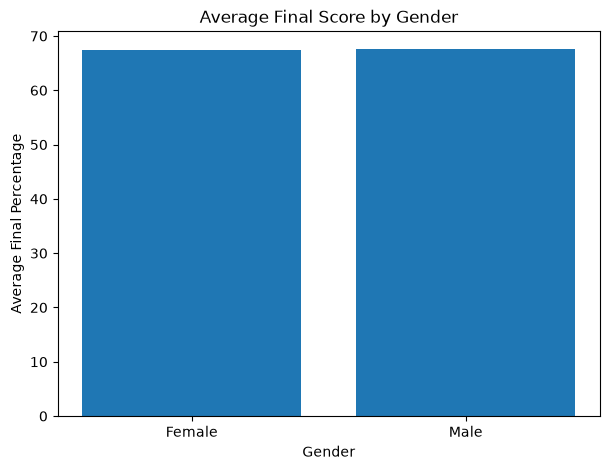

In [36]:
gender_performance = df.groupby('Gender')['Final_Percentage'].mean()

plt.figure(figsize=(7,5))
plt.bar(gender_performance.index, gender_performance.values)
plt.title('Average Final Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Percentage')
plt.show()

6. Pass Vs Fail Students

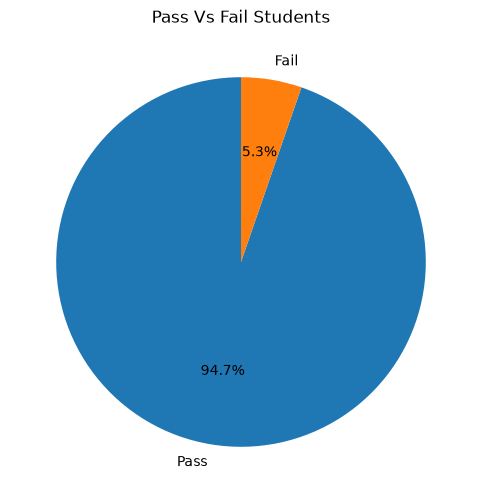

In [37]:
pass_fail_performance = df['Pass_Fail'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(pass_fail_performance,
        labels=pass_fail_performance.index,
       autopct='%1.1f%%',
       startangle=90)
plt.title("Pass Vs Fail Students")

plt.show()

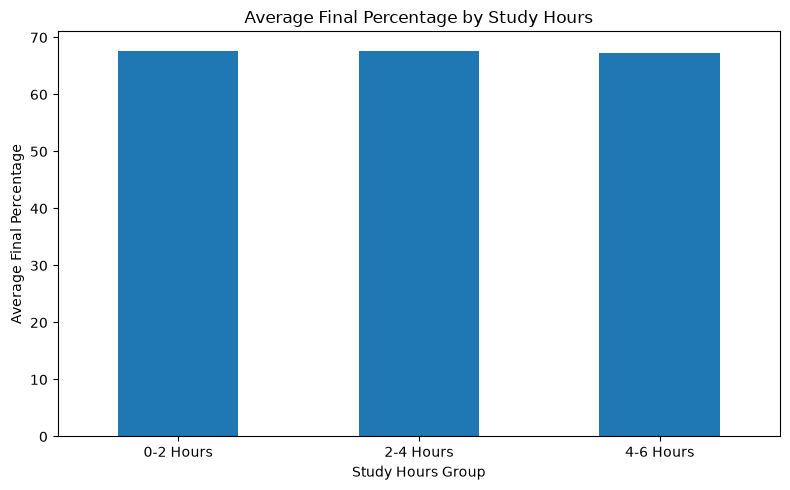

In [38]:
study_group_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Final Percentage by Study Hours")
plt.xlabel("Study Hours Group")
plt.ylabel("Average Final Percentage")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

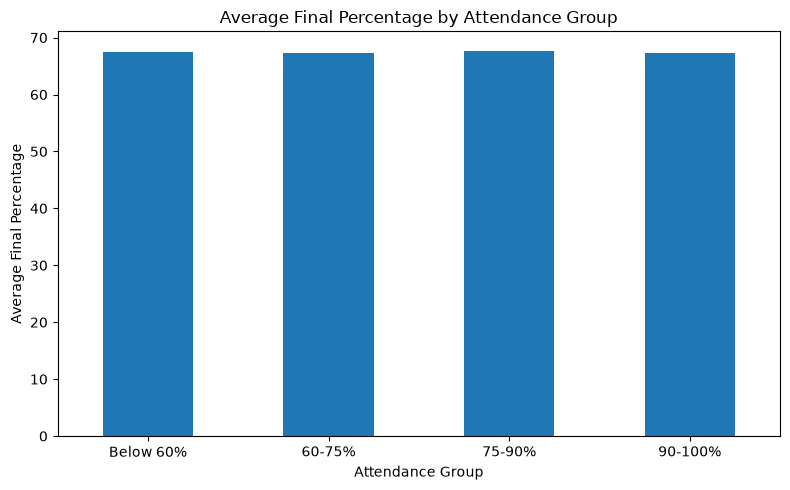

In [39]:
Attendance_Group_Analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Final Percentage by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Average Final Percentage")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Identify Top Students

In [40]:
top_students = df.sort_values( "Final_Percentage",ascending=False).head(10)

top_students[
    [
        "Student_ID",
        "Gender",
        "Study_Hours_Per_Day",
        "Attendance_Percentage",
        "Final_Percentage",
        "Performance_Level"
    ]
]

,Student_ID,Gender,Study_Hours_Per_Day,Attendance_Percentage,Final_Percentage,Performance_Level
21,S0022,Male,2.8,83,98.33,Excellent
3636,S3637,Female,3.8,90,97.67,Excellent
3748,S3749,Male,0.5,60,97.33,Excellent
2211,S2212,Male,1.8,87,97.33,Excellent
1599,S1600,Male,5.0,83,97.00,Excellent
4244,S4245,Female,1.3,57,97.00,Excellent
2196,S2197,Female,1.7,72,96.33,Excellent
4504,S4505,Female,1.1,59,96.00,Excellent
1968,S1969,Male,5.4,54,96.00,Excellent
3269,S3270,Female,5.2,88,96.00,Excellent


### Identify Students Who May Need Support

In [41]:
students_needing_support = df[
    (df["Attendance_Percentage"] < 75) &
    (df["Final_Percentage"] < 50)
]

print("Students needing attention:", len(students_needing_support))

Students needing attention: 123


In [42]:
students_needing_support[
    [
        "Student_ID",
        "Attendance_Percentage",
        "Study_Hours_Per_Day",
        "Final_Percentage",
        "Performance_Level",
        "Pass_Fail"
    ]
].head(10)

,Student_ID,Attendance_Percentage,Study_Hours_Per_Day,Final_Percentage,Performance_Level,Pass_Fail
97,S0098,66,2.3,48.33,Poor,Fail
119,S0120,55,4.5,43.33,Poor,Fail
261,S0262,55,1.3,44.33,Poor,Fail
270,S0271,65,1.6,46.00,Poor,Fail
291,S0292,61,4.1,42.00,Poor,Fail
350,S0351,69,3.0,46.67,Poor,Fail
355,S0356,50,4.4,47.33,Poor,Fail
393,S0394,72,4.7,47.33,Poor,Fail
401,S0402,56,2.5,46.67,Poor,Fail
528,S0529,65,2.9,47.00,Poor,Fail


## Summery Table

In [43]:
summary = pd.DataFrame({
    "Metric": [
        "Total Students",
        "Average Study Hours",
        "Average Attendance",
        "Average Math Score",
        "Average Science Score",
        "Average English Score",
        "Average Final Percentage",
        "Pass Percentage"
    ],
    
    "Value": [
        len(df),
        round(df["Study_Hours_Per_Day"].mean(), 2),
        round(df["Attendance_Percentage"].mean(), 2),
        round(df["Math_Score"].mean(), 2),
        round(df["Science_Score"].mean(), 2),
        round(df["English_Score"].mean(), 2),
        round(df["Final_Percentage"].mean(), 2),
        round((df["Pass_Fail"] == "Pass").mean() * 100, 2)
    ]
})

summary

,Metric,Value
0,Total Students,5000.00
1,Average Study Hours,3.29
2,Average Attendance,74.92
3,Average Math Score,67.75
4,Average Science Score,66.90
5,Average English Score,67.78
6,Average Final Percentage,67.48
7,Pass Percentage,94.70


## Export Cleaned Dataset into a new CSV file

In [51]:
df.to_csv(
    "../student_performance_cleaned.csv",
    index=False
)
print("File exported successfully.")

File exported successfully.


In [48]:
import os

os.path.exists("../student_performance_cleaned.csv")

True

In [50]:
cleaned_df = pd.read_csv(
    "../student_performance_cleaned.csv"
)
cleaned_df.shape

(5000, 19)

In [56]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail,Final_Score,Study_Hours_Group,Attendance_Group
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass,50.33,0-2 Hours,60-75%
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass,53.00,0-2 Hours,Below 60%
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass,71.67,2-4 Hours,60-75%
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass,64.33,4-6 Hours,60-75%
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail,41.00,4-6 Hours,75-90%


In [94]:
df.groupby('Extracurricular_Activities')['Final_Score'].mean()

Extracurricular_Activities
No     67.173083
Yes    67.777634
Name: Final_Score, dtype: float64

In [87]:
corre = df['Previous_Year_Score'].corr(df['Final_Percentage'])
corre

np.float64(-0.017252094875647373)

In [83]:
pass_student = (df['Pass_Fail']=='Pass').sum()
total_student = len(df)
overall_pass_student = pass_student/total_student*100
overall_pass_student

np.float64(94.69999999999999)

# Project Findings

In [96]:
print("""
1. STUDENT PERFORMANCE
- The average final percentage of students is 67.48%.
- The highest final percentage is 98.33%.
- The lowest final percentage is 36.33%.

2. SUBJECT PERFORMANCE
- The average Math score is 67.75.
- The average Science score is 66.90.
- The average English score is 67.78.
- English has the highest average score.
- Science has the lowest average score.

3. ATTENDANCE
- Students with higher attendance do not consistently show higher final scores.
- The relationship between attendance and final score is very weak/negligible, with a correlation of approximately 0.001.
- This suggests that, in this dataset, attendance is not strongly associated with academic performance.

4. STUDY HOURS
- Students who study for more hours do not consistently achieve higher final scores.
- The analysis shows a weak negative relationship between study hours and final performance.
- Students in the 3.6 hours/day study-hours category have the highest average final score of 70.20.
- Overall, the results suggest that more study hours alone do not guarantee better academic performance in this dataset.

5. PERFORMANCE LEVEL
- Most students fall under the "Good" performance level category.
- The number of students in the High Performance level category is 2191.
- The number of students in the Average Performance level category is 1951.
- The number of students in the Excellent Performance level category is 593.
- The number of students in the Poor Performance level category is 265.

6. PASS AND FAIL
- Total students who passed: 4735.
- Total students who failed: 265.
- Overall pass rate: 94.7%.
- The majority of students passed.

7. GENDER ANALYSIS
- Male students: 2447.
- Female students: 2553.
- The average final score of male students is 67.54.
- The average final score of female students is 67.42.
- Male Students has a higher average final score.

8. PREVIOUS YEAR PERFORMANCE
- Previous Year Score has a very weak negative relationship with Final Percentage. The correlation is -0.017, indicating almost no linear relationship between the two variables.
-Previous Year Score has almost no relationship with Final Percentage. Therefore, students who performed well in the previous year do not necessarily continue to perform well in the final percentage.

9. PARENTAL EDUCATION
- Students with parents having High School show the highest average performance.
- Students with parents having Postgraduation show the lowest average performance.
- Parental education appears to have a limited association with student performance, as the average scores across all education levels are very similar.

10. INTERNET ACCESS
- Students with internet access have an average final score of 67.42.
- Students without internet access have an average final score of 67.53.
- This indicates that internet access does not strongly affect academic performance in this dataset, as the average scores are nearly identical.

11. EXTRACURRICULAR ACTIVITIES
- Students participating in extracurricular activities have an average final score of 67.78.
- Students not participating have an average final score of 67.17.
- The difference suggests that extracurricular participation has limited impact on academic performance.

12. OVERALL FINDING
- Attendance, study hours, previous academic performance and other student-related factors were analyzed to understand academic performance.
- The analysis shows that English Score has the strongest relationship with Final Percentage, with a correlation of 0.592.
- Attendance and Study Hours show very weak relationships with Final Percentage in this dataset.
- Previous Year Score, Age, and Class also show very weak relationships with Final Percentage.
- Identifying low-performing students can help teachers provide additional academic support and targeted guidance.
""")


1. STUDENT PERFORMANCE
- The average final percentage of students is 67.48%.
- The highest final percentage is 98.33%.
- The lowest final percentage is 36.33%.

2. SUBJECT PERFORMANCE
- The average Math score is 67.75.
- The average Science score is 66.90.
- The average English score is 67.78.
- English has the highest average score.
- Science has the lowest average score.

3. ATTENDANCE
- Students with higher attendance do not consistently show higher final scores.
- The relationship between attendance and final score is very weak/negligible, with a correlation of approximately 0.001.
- This suggests that, in this dataset, attendance is not strongly associated with academic performance.

4. STUDY HOURS
- Students who study for more hours do not consistently achieve higher final scores.
- The analysis shows a weak negative relationship between study hours and final performance.
- Students in the 3.6 hours/day study-hours category have the highest average final score of 70.20.
- Overal

## Short Summery

- **English Score has the strongest relationship with Final Percentage**, followed by Science Score and Math Score.
- **Attendance shows almost no relationship with Final Percentage** in this dataset.
- **Study Hours show almost no relationship with Final Percentage** in this dataset.
- **Previous Year Score also shows almost no relationship with Final Percentage**, so it is not a strong indicator of final performance in this dataset.
- **Subject-wise analysis helps identify stronger and weaker academic areas** based on students' performance in individual subjects.
- **Performance-level analysis helps identify Excellent, Good, Average, and Poor-performing students.**
- **Pass/Fail analysis provides an overview of overall student success and failure rates.**
- **Parental Education, Internet Access, and Extracurricular Activities can be compared to understand their association with student performance.**
- **Identifying low-performing students can help teachers provide additional academic support and targeted guidance.**
